In [1]:
import pandas as pd
import numpy as np

n = 500 # 500줄
np.random.seed(42) # 랜덤 시작 점 42상태에서 난수 생성

df = pd.DataFrame({

    # 시간: 1시간 간격의 데이터 생성
    'time': pd.date_range('2026-06-08', periods=n, freq='h'),
    
    # 온도(섭씨): 25도 전후 (초여름 날씨 가정)
    'temperature_c': np.random.normal(25, 3, n), 
    
    # 습도(%): 60% 전후 (일반적인 습도)
    'humidity_percent': np.random.normal(60, 10, n), 
    
    # 풍속(m/s): 3m/s 전후 (나뭇잎이 흔들리는 가벼운 바람 수준)
    'wind_speed_ms': np.random.normal(3, 1.5, n)

    
})

df
print(df.shape)
df

(500, 4)


,time,temperature_c,humidity_percent,wind_speed_ms
0,2026-06-08 00:00:00,26.490142,69.261775,5.099033
1,2026-06-08 01:00:00,24.585207,79.094166,4.386951
2,2026-06-08 02:00:00,26.943066,46.014324,3.089446
3,2026-06-08 03:00:00,29.569090,65.629692,2.029595
4,2026-06-08 04:00:00,24.297540,53.493574,4.047335
...,...,...,...,...
495,2026-06-28 15:00:00,26.616730,57.188997,6.009139
496,2026-06-28 16:00:00,21.888262,77.976865,6.092255
497,2026-06-28 17:00:00,24.428984,66.408429,4.812549
498,2026-06-28 18:00:00,22.373145,54.288210,4.536094


In [3]:
# 결측 치 : 30 개 무작위로 NaN 처리
idx = np.random.choice(df.index, size=30, replace=False)
df.loc[idx, 'humidity_percent'] = np.nan

# 이상치 : 5개를 비정상 고온으로 
df.loc[df.index[:5], 'temperature_c'] = df['temperature_c'] + 15 # 15도 더해서 이상치 생성

# 중복: 앞 3행 통째로 복제해 추가
df = pd.concat([df, df.iloc[:3]], ignore_index=True)

# 자료형 오류 : 풍속을 문자열로 변환
df['wind_speed_ms'] = df['wind_speed_ms'].astype(str) + ' m/s'
df.to_csv('weather_data.csv', index=False) # 저장

PermissionError: [Errno 13] Permission denied: 'weather_data.csv'

In [4]:
df = pd.read_csv('weather_data.csv') # 불러오기

print(df.info()) # 자료형 결측 개수 한눈에
print(df.isnull().sum()) # 결측치 개수 확인
print(df.duplicated().sum()) # 중복 개수 확인
print(df.describe()) # 수치형 데이터 요약 통계량





<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              503 non-null    str    
 1   temperature_c     503 non-null    float64
 2   humidity_percent  473 non-null    float64
 3   wind_speed_ms     503 non-null    str    
dtypes: float64(2), str(2)
memory usage: 15.8 KB
None
time                 0
temperature_c        0
humidity_percent    30
wind_speed_ms        0
dtype: int64
3
       temperature_c  humidity_percent
count     503.000000        473.000000
mean       25.264961         60.370795
std         3.568444          9.813570
min        15.276198         33.031134
25%        22.911047         54.231081
50%        25.105791         60.473987
75%        27.023905         66.748195
max        44.569090         86.323821


In [5]:
# 결측이 있는 행 전체 삭제 
df_drop = df.dropna()
print(len(df), '->', len(df_drop))

# 특정 컬럼 기준으로만 삭제 
df2 = df.dropna(subset=['humidity_percent'])

#결측이 너무 많은 '열' 삭제 (예: 50% 이상 )
df3=df.dropna(axis=1, thresh=int(0.5*len(df)))


503 -> 473


In [8]:
# 평균값으로 채우기
df_mean = df.copy()
df_mean['humidity_percent'] = df_mean['humidity_percent'].fillna(df_mean['humidity_percent'].mean())
print(df_mean['humidity_percent'][:8])
#print("==============")

# 중앙값으로 채우기 
df_median = df.copy()
df_median['humidity_percent'] = df_median['humidity_percent'].fillna(df_median['humidity_percent'].median())
#print(df_median)
#print("==============")

# 직전 값으로 채우기 
df_ffill = df.copy()
df_ffill['humidity_percent'] = df_ffill['humidity_percent'].ffill()
#print(df_ffill)
#print("==============")

0    69.261775
1    79.094166
2    46.014324
3    65.629692
4    53.493574
5    60.370795
6    54.076061
7    51.360092
Name: humidity_percent, dtype: float64


In [9]:
print("원본 결측치 개수")
print(df['humidity_percent'].isnull().sum())

print("평균값으로 채운 후 결측치 개수")
print(df_mean['humidity_percent'].isnull().sum())

print("중앙값으로 채운 후 결측치 개수")
print(df_median['humidity_percent'].isnull().sum())

print("fill 대체 후 결측치 개수")
print(df_ffill['humidity_percent'].isnull().sum())



원본 결측치 개수
30
평균값으로 채운 후 결측치 개수
0
중앙값으로 채운 후 결측치 개수
0
fill 대체 후 결측치 개수
0


In [10]:
# temperature_c 컬럼에서 결측치는 잠시 제외하고 IQR 계산
temp_data = df['temperature_c'].dropna()
Q1 = temp_data.quantile(0.25)
Q3 = temp_data.quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("정상 범위:",  low, "~", high)

# 정상 범위 안의 값만 남기기 
mask = (df['temperature_c'] >= low) & (df['temperature_c'] <= high)
df_clean = df[mask]
print("원본 행 개수 :", len(df))
print("IQR로 이상치 제거 후 행 개수 :", len(df_clean))
print("이상치 제거 후 temperature_c 요약 통계량:", df_clean['temperature_c'].max())




Q1: 22.911047345120142
Q3: 27.02390544664707
IQR: 4.112858101526928
정상 범위: 16.74176019282975 ~ 33.193192598937465
원본 행 개수 : 503
IQR로 이상치 제거 후 행 개수 : 492
이상치 제거 후 temperature_c 요약 통계량: 33.160507499768855


In [11]:
# Z- Score로 이상치 탐지 
temp_data = df['temperature_c'].mean()
mean = df['temperature_c'].mean()
std = df['temperature_c'].std()
df_z = df.copy()
df_z['z'] = (df_z['temperature_c'] - mean) / std
df_z_clean = df_z[df_z['z'].abs() <= 3]
print("Z-Score로 기준 이상치 제거 후 행 개수 :", len(df_z_clean))
print("Z-Score로 이상치 제거 후 temperature_c 요약 통계량:", df_z_clean['temperature_c'].max())




Z-Score로 기준 이상치 제거 후 행 개수 : 494
Z-Score로 이상치 제거 후 temperature_c 요약 통계량: 34.23664242536572


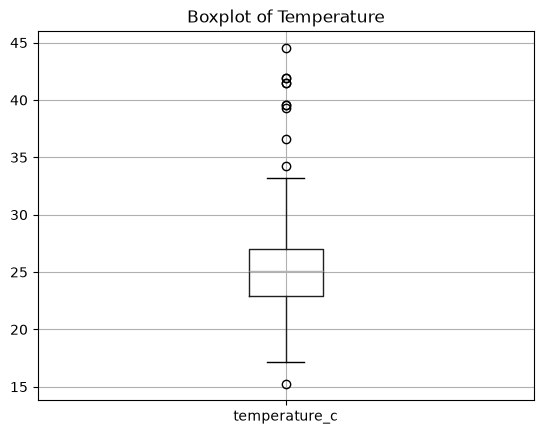

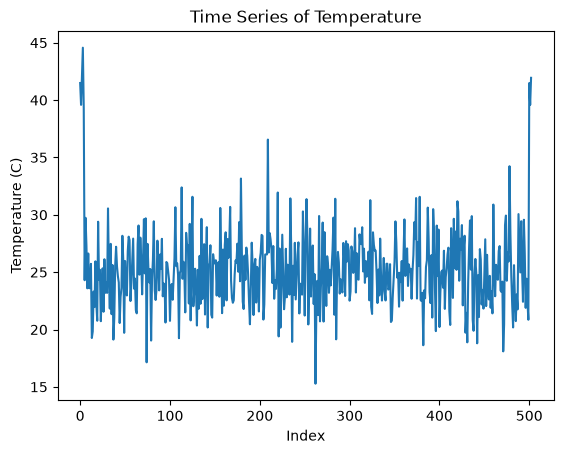

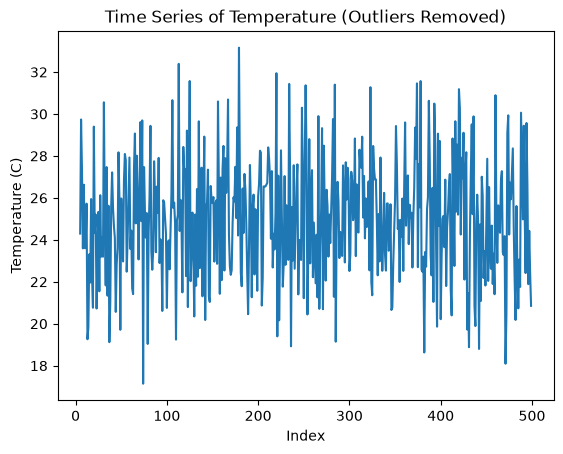

In [12]:
import matplotlib.pyplot as plt
# 시각화로 이상치 확인
import matplotlib.pyplot as plt
# 박스플롯 이상치가 점으로 튀어나옴
df.boxplot(column='temperature_c')
plt.title('Boxplot of Temperature')
plt.show()


#시계열 선 그래프 44 지점 위로 솟구침 
df['temperature_c'].plot(title='Time Series of Temperature')
plt.xlabel('Index')
plt.ylabel('Temperature (C)')
plt.show()

# 이상치 제거 후 다시 확인
df_clean['temperature_c'].plot(title='Time Series of Temperature (Outliers Removed)')
plt.xlabel('Index')
plt.ylabel('Temperature (C)')
plt.show()

In [14]:
# 중복 행 제거 
print(df.duplicated().sum()) # 중복 개수 확인
df = df.drop_duplicates()
print(df)

#문자열 -> 숫자 변환
df['wind_speed_ms'] = pd.to_numeric(df['wind_speed_ms'], errors='coerce') # 변환 불가한 값은 NaN으로 처리


# 문자열 -> 날짜 변환
df['time'] = pd.to_datetime(df['time'], errors='coerce') # 변환 불가한 값은 NaT로 처리
print(df.dtypes)
print(df['time'])

0
                   time  temperature_c  humidity_percent  wind_speed_ms
0   2026-06-08 00:00:00      41.490142         69.261775            NaN
1   2026-06-08 01:00:00      39.585207         79.094166            NaN
2   2026-06-08 02:00:00      41.943066         46.014324            NaN
3   2026-06-08 03:00:00      44.569090         65.629692            NaN
4   2026-06-08 04:00:00      39.297540         53.493574            NaN
..                  ...            ...               ...            ...
495 2026-06-28 15:00:00      26.616730         57.188997            NaN
496 2026-06-28 16:00:00      21.888262         77.976865            NaN
497 2026-06-28 17:00:00      24.428984         66.408429            NaN
498 2026-06-28 18:00:00      22.373145         54.288210            NaN
499 2026-06-28 19:00:00      20.851601         65.725828            NaN

[500 rows x 4 columns]
time                datetime64[us]
temperature_c              float64
humidity_percent           float64
wind_

In [29]:
#기준 데이터 선택 : 이상치 제거 후 데이터 사용
df_scale = df_clean.copy()

#결측치가 남아 있다면 중앙값으로 대체 
df_scale['humidity_percent'] = df_scale['humidity_percent'].fillna(df_scale['humidity_percent'].median())

#방법 A) Min-Max 정규화: 0~1 사이로 스케일링
c = df_scale['temperature_c']
df_scale['temperature_c_scaled'] = (c - c.min()) / (c.max() - c.min())

# 방법 B) StandardScaler 표준화 (숫자형 컬럼만)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['temperature_c', 'humidity_percent']  # wind_speed_ms는 문자열이므로 제외

df_scale[cols] = scaler.fit_transform(df_scale[cols])
print(df_scale[cols].describe())

       temperature_c  humidity_percent
count   4.920000e+02      4.920000e+02
mean    2.112132e-16      8.953994e-16
std     1.001018e+00      1.001018e+00
min    -2.756617e+00     -2.900325e+00
25%    -7.361874e-01     -6.245739e-01
50%     1.753262e-02      1.481736e-02
75%     6.683313e-01      6.375882e-01
max     2.873498e+00      2.762725e+00


In [13]:
def clean_pipeline(path):
    df = pd.read_csv(path)

    # 1)자료형
    df['wind_speed_ms'] = pd.to_numeric(df['wind_speed_ms'], errors='coerce') # 변환 불가한 값은 NaN으로 처리
    df['time'] = pd.to_datetime(df['time'], errors='coerce') # 변환 불가한 값은 NaT로 처리
    # 종복 /3 ) 이상치(IQR)
    df = df.drop_duplicates() # 중복 제거
    Q1, Q3 = df['temperature_c'].quantile([0.25, 0.75])
    iqr = Q3 - Q1
    df = df[(df['temperature_c'] >= Q1 - 1.5*iqr) & (df['temperature_c'] <= Q3 + 1.5*iqr)]
    # 4)결측치 처리 : 중앙값으로 대체   
    df['humidity_percent'] = df['humidity_percent'].fillna(df['humidity_percent'].median())
    df.to_csv('weather_data_cleaned.csv', index=False)
    return df


In [14]:
df = clean_pipeline('weather_data.csv')

# 검증 모든 문제가 사려졌는지 확인
print(df.isnull().sum().sum())
print(df.duplicated().sum())
print(df['temperature_c'].max())
print(df.dtypes)

491
0
32.389726337455855
time                datetime64[us]
temperature_c              float64
humidity_percent           float64
wind_speed_ms              float64
dtype: object
